# 1. Data Loading & Inspection

In [9]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [11]:
df.shape

(891, 12)

In [13]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [15]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

# 2. Univariate Analysis

### 1. Age
**conclusions**
* Passenger ages range from infants to elderly individuals.
* Most passengers are young adults.
* The distribution is slightly right-skewed.
* A few elderly passengers appear as potential outliers.

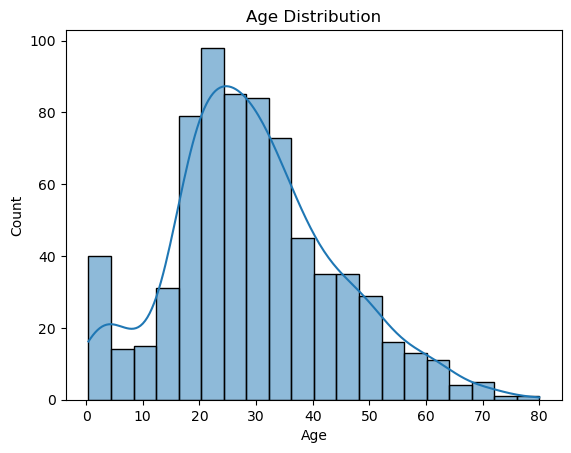

In [61]:
sns.histplot(df['Age'], kde=True)
plt.title('Age Distribution')
plt.show()

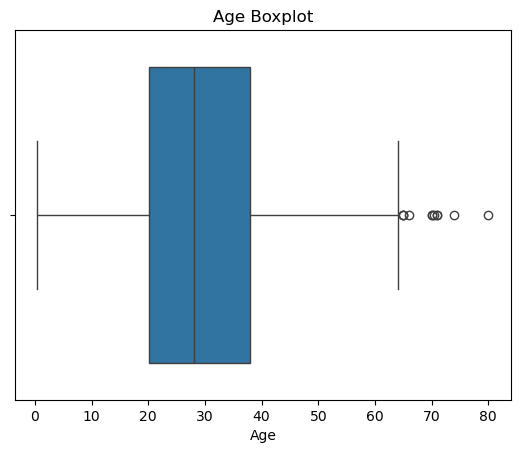

In [62]:
sns.boxplot(x=df['Age'])
plt.title('Age Boxplot')
plt.show()

In [30]:
df['Age'].skew()

np.float64(0.38910778230082704)

### 2. Fare 
**conclusions**
* Fare values vary considerably among passengers.
* The distribution is highly right-skewed.
* Most passengers paid relatively low fares.
* Several high-fare outliers are present.

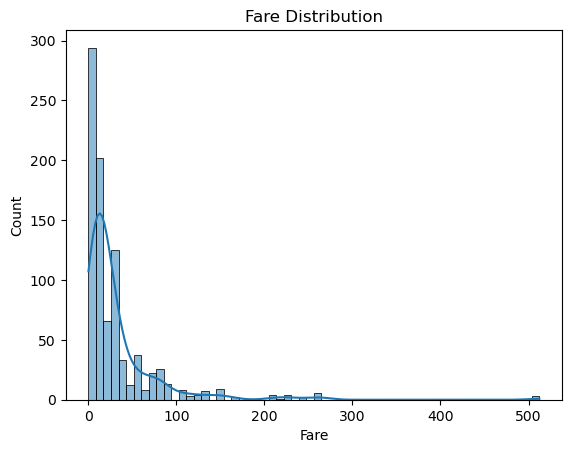

In [59]:
sns.histplot(df['Fare'], kde=True)
plt.title('Fare Distribution')
plt.show()

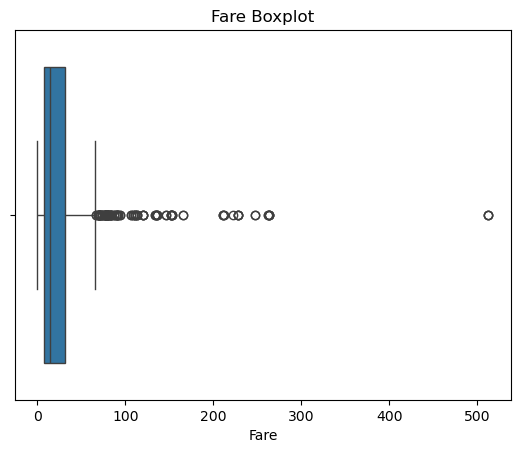

In [60]:
sns.boxplot(x=df['Fare'])
plt.title('Fare Boxplot')
plt.show()

## 3. survived
**conclusions**
* The majority of passengers did not survive.
* Approximately 62% of passengers died, while about 38% survived.
* The target variable shows moderate class imbalance.

In [57]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

<Axes: ylabel='count'>

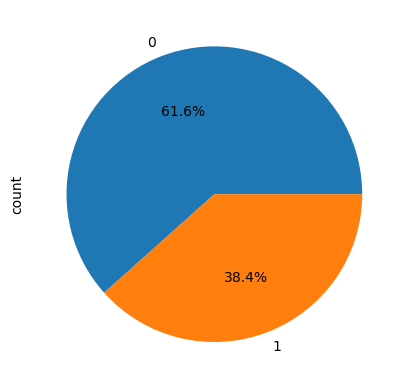

In [63]:
df['Survived'].value_counts().plot(kind ='pie',autopct = '%0.1f%%')

## 4. Passenger Class (Pclass)
**conclusion**
* Third-class passengers constitute the largest group in the dataset, accounting for more than half of all passengers.
* First-class passengers represent the second largest group.
* Second-class passengers form the smallest group among the three travel classes.
* The distribution of passenger classes is imbalanced, with a strong concentration of passengers in third class.

In [65]:
df['Pclass'].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

<Axes: xlabel='Pclass'>

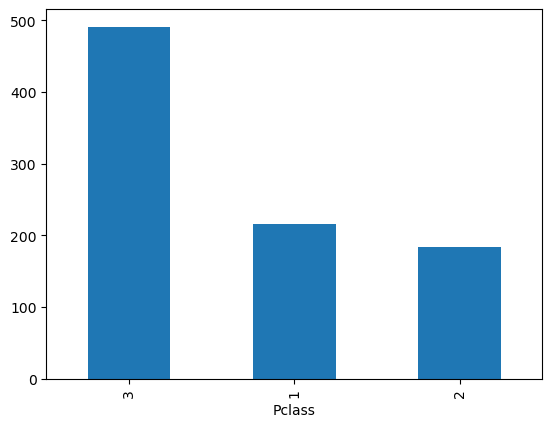

In [68]:
df['Pclass'].value_counts().plot(kind = 'bar')

### 5. Gender Distribution (Sex)
**conclusion**
* Male passengers significantly outnumber female passengers.
* The gender distribution is not balanced.

In [70]:
df['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

<Axes: xlabel='Sex'>

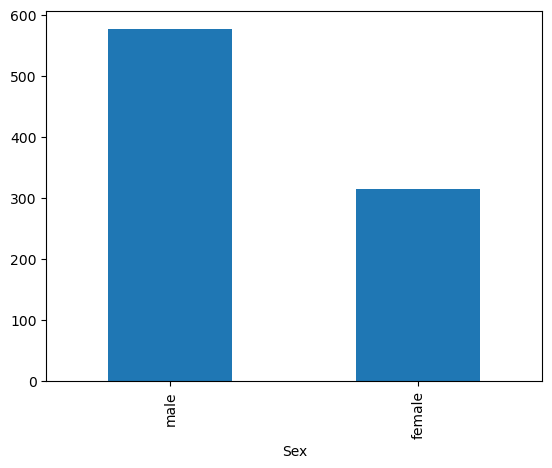

In [72]:
df['Sex'].value_counts().plot(kind='bar')

### 6. Embarkation Port (Embarked)
**conclusion**

In [74]:
df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

Text(0.5, 1.0, 'Embarkation Port Distribution')

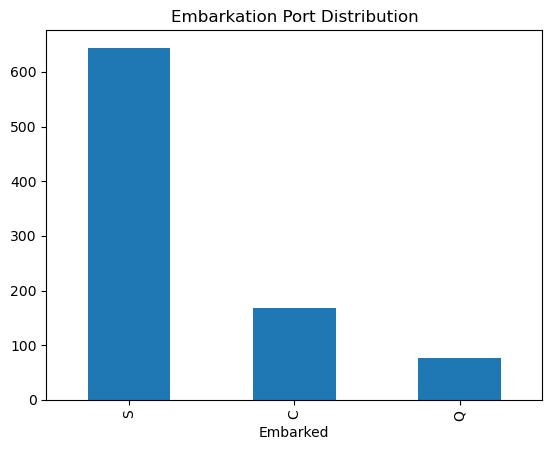

In [76]:
df['Embarked'].value_counts().plot(kind = 'bar')
plt.title('Embarkation Port Distribution')

# 3. Bivariate Analysis

<Axes: xlabel='Pclass', ylabel='Survived'>

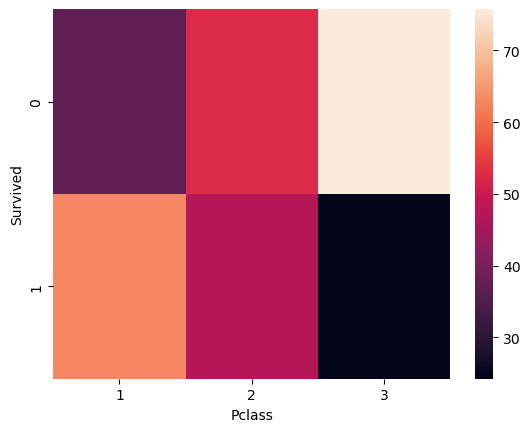

In [38]:
sns.heatmap(pd.crosstab(df['Survived'],df['Pclass'], normalize = 'columns')*100)

In [41]:
pd.crosstab(df['Survived'],df['Sex'], normalize = 'columns')*100

Sex,female,male
Survived,,
0,25.796178,81.109185
1,74.203822,18.890815


In [45]:
pd.crosstab(df['Survived'],df['Embarked'], normalize = 'columns')*100

Embarked,C,Q,S
Survived,,,
0,44.642857,61.038961,66.304348
1,55.357143,38.961039,33.695652


In [47]:
pd.crosstab(df['Sex'],df['Embarked'], normalize = 'columns')*100

Embarked,C,Q,S
Sex,,,
female,43.452381,46.753247,31.521739
male,56.547619,53.246753,68.478261


In [49]:
pd.crosstab(df['Pclass'],df['Embarked'], normalize = 'columns')*100

Embarked,C,Q,S
Pclass,,,
1,50.595238,2.597403,19.720497
2,10.119048,3.896104,25.465839
3,39.285714,93.506494,54.813665


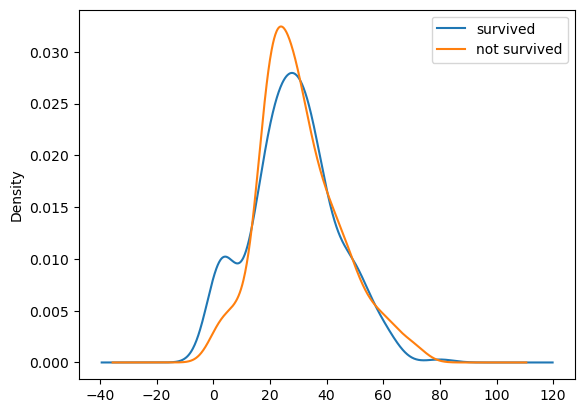

In [54]:
df[df['Survived'] == 1]['Age'].plot(kind = 'kde',label='survived')
df[df['Survived'] == 0]['Age'].plot(kind = 'kde',label='not survived')
plt.legend()

# 5. Correlation Analysis

# 6. Key Findings & Insights